In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, mean_squared_error, r2_score)


In [36]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/Food Insecurity Analysis/datasets/cleaned_for_eda&modeling/unified_dataset_for_modeling.csv')

In [37]:
df.head()

,nta_id,nta_name,borough,food_insecure_percentage,food_insecure_percentage_rank,unemployment_rate,unemployment_rate_rank,vulnerable_population_percentage,vulnerable_population_percentage_rank,supply_gap,...,is_high_priority,coverage_category,coverage_category_label,has_kitchen,has_weekend,log_total_sites,log_coverage_ratio,priority_normalized,is_low_coverage,is_high_coverage
0,BK0104,East Williamsburg,Brooklyn,35.99,1,6.38,126,12.43,146,2.776626e+06,...,1,0,Low,0,0,0.693147,0.027406,1.000000,1,0
1,BX0501,University Heights (South)-Morris Heights,Bronx,29.44,14,11.98,20,19.63,34,1.669389e+06,...,1,0,Low,0,0,1.386294,0.097038,0.977019,1,0
2,BX0901,Soundview-Bruckner-Bronx River,Bronx,22.63,36,10.06,32,21.43,25,1.625976e+06,...,1,1,High,1,1,1.609438,0.162762,0.918451,0,1
3,MN1202,Washington Heights (North),Manhattan,24.29,28,12.25,19,18.57,41,1.463457e+06,...,1,0,Low,1,0,1.098612,0.079124,0.873113,1,0
4,BK1503,Sheepshead Bay-Manhattan Beach-Gerritsen Beach,Brooklyn,21.11,42,4.91,170,15.95,81,1.907056e+06,...,1,0,Low,1,0,0.693147,0.046283,0.856022,1,0


we will be building a logistic regression models to predict the coverage category of food insecurity based on various socio-economic and demographic features. We will prepare the data, train the models, and evaluate their performances using appropriate metrics (Accuracy, Precision, Recall).

TARGET VARIABLE: coverage_category (0 = Low Coverage, 1 = High Coverage)

We will build and compare:
1. Model 1: Core Features (L2 regularization)
2. Model 2: Core Features (L1 regularization)
3. Model 3: Extended Features (L2 regularization)

we first need to look at Regularization which is a technique used to prevent overfitting (where the model memorizes the training data, including the noise, instead of learning the actual patterns).

### What Each Model Does
1. Model 1: Core Features + L2 Regularization
    - This model is considered as the baseline, it is most simplest reasonable model, we will be using this one to compare it to other models for improvement. This model only uses the core socio-economic features `food_insecure_percentage`, `unemployment_rate`, `vulnerable_population_percentage`, `is_high_priority`. This model predicts whether an area has Low (0) or High (1) food insecurity coverage using only the core socio-economic indicators.
    - These features are called "CORE" because they are the PRIMARY need indicators directly from the NYC Neighborhood Prioritization datase, so these variables represent the fundamental dimensions of neighborhood need that the city uses for prioritization.

2. Model 2: Core Features + L1 Regularization
    - This model uses the same core features as the baseline, but may eliminate all the weaker predictors entirely because L1 Regularization can shrink so coefficient to exactly zero, eliminating the possibility of overfitting the data. This performs automatic feature selection. So, if the one variable has low predictive power, L1 delete automatically. 

3. Model 3: Extended Features + L2 Regularization
    - This model is most complexe one. It uses all the core features plus other variables `high_shelter_flag`, `has_kitchen`, `has_weekend`. It includes both the socio-economic factors and operations / service avaibility indicators with L2 regularization to prevent overfitting. We call them extended features because the high shelter flag comes from a different dataset (Shelter Census). We want to see weather adding more features improves the model predictions.

### What is L1 vs L2 Regularization?
- Regularization is all about preventing overfitting data when performing a logistic regression model.
    - L1 performs features selection by shrinking the coefficient to 0 of all the underperforming variable by preventing overfitting. 
    - L2 shrinks coefficients smoothly by keeping all variables. It performs better specially when features are correlated


#### ASSUMPTION: 
In order to build a logistic regression model, we need check and validate some assumption first like:
- Linearity of Log-Odds: in this case all of our independant variables are positive numbers ranging from 0 to ∞. 
- Independence: this assumption is satisfied here because each NTA is an independent geographic unit. Observations are not paired or repeated measures and each neighborhood appears once in the dataset.
- No Severe Multicollinearity: this one also is satified, the VIF score perfomed in the statistic notebook confirmed that all the core and extended features used to build the logistic regression model are not highly correlated from each other. (See the statistic note for reference, or you can also check the VIF score of all the variable used to build the model bellow)
- Large Sample Size: Our sample is large enough to enough to provide a stable and reliable coefficient estimates.

### CHECKING

### Multicollinearity
- We calculated Variance Inflation Factor (VIF) scores for both the core and extended feature sets to assess multicollinearity. (see statistics notebook)
- All selected features have VIF values well below the common threshold of 5, indicating:
    - No severe multicollinearity
    - Features are not highly linearly dependent on one another
    - Model coefficients should remain stable and interpretable
    - Even in the extended model, which includes shelter concentration indicators, VIF values remain low (all near ~1–1.7), suggesting that each feature contributes unique explanatory information.
    Here are the results in the table below:

### Core Features

| Feature                           | VIF       | Status |
|-----------------------------------|-----------|--------|
| food_insecure_percentage          | 1.490467  | OK     |
| unemployment_rate                 | 1.417832  | OK     |
| is_high_priority                  | 1.382031  | OK     |
| vulnerable_population_percentage  | 1.054950  | OK     |

### Extended Features

| Feature                           | VIF       | Status |
|-----------------------------------|-----------|--------|
| food_insecure_percentage          | 1.508703  | OK     |
| unemployment_rate                 | 1.797042  | OK     |
| is_high_priority                  | 1.415930  | OK     |
| vulnerable_population_percentage  | 1.061910  | OK     |
| has_weekend                       | 1.329249  | OK     |
| has_kitchen                       | 1.190224  | OK     |
| high_shelter_flag                 | 1.275522  | OK     |


### Key Takeaway
- Our selected predictors are statistically suitable for logistic regression. There is no evidence of problematic multicollinearity that would distort coefficient estimates or inflate standard errors. This confirms that we can proceed with modeling using these features with confidence.
### Sample Size
- Total Sample Size: N = 197 NTAs (Neighborhood Tabulation Areas)
- Train/Test Split:
    - Training set: n = 147
    - Test set: n = 50
    - We will be training our model on 75% of our hole dataset and testing it with the remaining 25%


- All these assumptions are correct, so we can procede to the models building.

In [38]:
#  Preparing Data for Modeling
# Select relevant features and target variable
# Define feature sets
core_features = ['food_insecure_percentage', 'unemployment_rate', 
                 'vulnerable_population_percentage', 'is_high_priority']

extended_features = ['food_insecure_percentage', 'unemployment_rate', 
                     'vulnerable_population_percentage', 'is_high_priority',
                     'high_shelter_flag', 'has_kitchen', 'has_weekend']

In [39]:
# Target variable 
# 0 → Low coverage, 1 → High coverage
y = df['coverage_category'].values

# Core features
X_core = df[core_features].values

# Extended features
X_extended = df[extended_features].values

# Train-test split (stratified)
X_core_train, X_core_test, y_train, y_test = train_test_split(
    X_core, y, test_size=0.25, random_state=42, stratify=y
)

X_ext_train, X_ext_test, _, _ = train_test_split(
    X_extended, y, test_size=0.25, random_state=42, stratify=y
)

In [40]:
print(f"Training set: {len(y_train)} samples")
print(f"Test set: {len(y_test)} samples")

Training set: 147 samples
Test set: 50 samples


- Let's check if the data is balanced before runing and chosing the model.
- If the data is balanced, the metric we will be using to select the best performing model will be a `Accuracy`, but if the data is not balanced, we will be using a other metrics like `Recall` or `Precision` because accurage would be miseleading as the model will most likely give prediction on the most dominant variable. 

In [41]:
n_total = len(df)
n_high_coverage = df['coverage_category'].sum()
n_low_coverage = n_total - n_high_coverage

In [42]:
print(f"""CLASS BALANCE: {'BALANCED' if 0.4 < n_high_coverage/n_total < 0.6 else 'IMBALANCED'}
  (Classes are nearly 50/50, so accuracy is a valid metric)""")

CLASS BALANCE: BALANCED
  (Classes are nearly 50/50, so accuracy is a valid metric)


- Let’s scale the data to ensure all the variables we are using are on the same scale. This is a critical step when building a logistic regression model. Even though the model will still run without scaling, we get more reliable results when the data is scaled. Some variables can have much larger values than others, and scaling puts them on a similar range so the model can better learn the patterns and predict the outcome.

In [43]:
# Scale features
scaler_core = StandardScaler()
X_core_train_scaled = scaler_core.fit_transform(X_core_train)
X_core_test_scaled = scaler_core.transform(X_core_test)

scaler_ext = StandardScaler()
X_ext_train_scaled = scaler_ext.fit_transform(X_ext_train)
X_ext_test_scaled = scaler_ext.transform(X_ext_test)

In [44]:
print("Model 1: Core Features + L2 Regularization (Ridge)")
model1 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000)
model1.fit(X_core_train_scaled, y_train)

y_pred_m1 = model1.predict(X_core_test_scaled)
y_prob_m1 = model1.predict_proba(X_core_test_scaled)[:, 1]

print(f"Coefficients: {dict(zip(core_features, model1.coef_[0].round(4)))}")
print(f"Intercept: {model1.intercept_[0]:.4f}")

# Let's get the accuracy score

cv_scores_m2 = cross_val_score(model1, X_core_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores_m2.mean():.4f}")

Model 1: Core Features + L2 Regularization (Ridge)
Coefficients: {'food_insecure_percentage': np.float64(-0.7408), 'unemployment_rate': np.float64(0.8149), 'vulnerable_population_percentage': np.float64(0.0682), 'is_high_priority': np.float64(-0.2531)}
Intercept: -0.0049
Cross-validation Accuracy: 0.6464


In [45]:
coef_Score = model1.coef_[0][0]
intercept = model1.intercept_[0]
print(f"Intercept (Log-Odds): {intercept:.4f}")
print(f"Coefficient (Log-Odds): {coef_Score:.4f}")

Intercept (Log-Odds): -0.0049
Coefficient (Log-Odds): -0.7408


In [46]:
# --- Convert to Odds Ratios ---
model1_odds = np.exp(intercept)

odds_ratio_food_insecure_percentage = np.exp(coef_Score)
odds_ratio_unemployment_rate = np.exp(model1.coef_[0][1])
odds_ratio_vulnerable_population_percentage = np.exp(model1.coef_[0][2])
odds_ratio_is_high_priority = np.exp(model1.coef_[0][3])

print(f"\nModel1 Odds: {model1_odds:.4f}")

print(f"Odds Ratio for Food Insecurity: {odds_ratio_food_insecure_percentage:.4f}")
print(f"Odds Ratio for Unemployment Rate: {odds_ratio_unemployment_rate:.4f}")
print(f"Odds Ratio for Vulnerable Population Percentage: {odds_ratio_vulnerable_population_percentage:.4f}")
print(f"Odds Ratio for Is High Priority: {odds_ratio_is_high_priority:.4f}")


Model1 Odds: 0.9952
Odds Ratio for Food Insecurity: 0.4768
Odds Ratio for Unemployment Rate: 2.2591
Odds Ratio for Vulnerable Population Percentage: 1.0706
Odds Ratio for Is High Priority: 0.7764


#### Interpretaion: 
food_insecure_percentage (coef = -0.7408):

- A 1 standard deviation increase in food insecurity is associated with a 52% DECREASE in the odds of being a high-coverage area
- This confirms our hypothesis: higher food insecurity neighborhood have lower coverage. 




unemployment_rate (coef = +0.8149):

- A 1 standard deviation increase in unemployment is associated with a 126% INCREASE in the odds of being a high-coverage area
- This suggests food programs may be successfully targeting economically distressed areas, OR unemployment captures different vulnerability than food insecurity

is_high_priority (coef = -0.2531):

- Being a high-priority neighborhood is associated with 22% LOWER odds of having high coverage
- Confirms the service gap hypothesis


vulnerable_population_percentage (coef = +0.0682):

- This variable has a minimal effect only 7% increase in odds per Standard deviation. It is not a strong predictor. 

Classifying each feature by absolute coefficient, here are the most important:

1. unemployment_rate 0.8149 is the most important
2. food_insecure_percentage 0.7408 is the 2nd most important
3. is_high_priority is ranked 3rd with a value of 0.2531 
4. vulnerable_population_percentage is the least important feature with a value of 0.0682

### Takeaway
After fitting the logistic regression model using the core socio-economic features with L2 regularization, we examined the model coefficients and intercept to understand how each variable influences the prediction of food coverage category. Because the features were standardized prior to modeling, the coefficients can be directly compared in terms of their relative influence. A positive coefficient indicates that higher values of that feature increase the likelihood of predicting High Coverage (1), while a negative coefficient suggests the opposite. In this model, unemployment rate had a strong positive association with high coverage, while food insecurity percentage had a negative association, suggesting that areas with higher food insecurity were less likely to be classified as having high food coverage. The vulnerable population percentage showed a relatively small effect in comparison. The intercept represents the baseline log-odds of predicting high coverage when all scaled features are at their mean values.

To evaluate model performance, we conducted 5-fold cross-validation using accuracy as the scoring metric. The average cross-validation accuracy of approximately 64.6% indicates that the model correctly classifies neighborhoods about two-thirds of the time on unseen training splits. This suggests the model performs better than random guessing, though there is still room for improvement. Cross-validation helps ensure that the model’s performance is not dependent on a single train-test split and provides a more stable estimate of its predictive reliability.

In [47]:
# Model 2: Core Features with L1 Regularization (Lasso)
print("Model 2: Core Features + L1 Regularization (Lasso)")

model2 = LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=1000)
model2.fit(X_core_train_scaled, y_train)

y_pred_m2 = model2.predict(X_core_test_scaled)
y_prob_m2 = model2.predict_proba(X_core_test_scaled)[:, 1]

print(f"Coefficients: {dict(zip(core_features, model2.coef_[0].round(4)))}")
print(f"Intercept: {model2.intercept_[0]:.4f}")

cv_scores_m2 = cross_val_score(model2, X_core_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores_m2.mean():.4f}")


Model 2: Core Features + L1 Regularization (Lasso)
Coefficients: {'food_insecure_percentage': np.float64(-0.7247), 'unemployment_rate': np.float64(0.7867), 'vulnerable_population_percentage': np.float64(0.0355), 'is_high_priority': np.float64(-0.2169)}
Intercept: -0.0026
Cross-validation Accuracy: 0.6464


### Takeaway
Model 2 applied L1 regularization to the same core socio-economic features to evaluate whether automatic feature selection would improve performance. Unlike L2, L1 regularization can shrink coefficients to zero, effectively removing weak predictors. However, in this case, none of the coefficients were eliminated, and the cross-validation accuracy remained identical to Model 1 (approximately 64.6%). This suggests that all core features contribute meaningfully to the model and that switching from L2 to L1 regularization does not materially change predictive performance for this feature set.

In [48]:
print("Model 3: Extended Features + L2 Regularization")

model3 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', random_state=42, max_iter=1000)
model3.fit(X_ext_train_scaled, y_train)

y_pred_m3 = model3.predict(X_ext_test_scaled)
y_prob_m3 = model3.predict_proba(X_ext_test_scaled)[:, 1]

print(f"Coefficients: {dict(zip(extended_features, model3.coef_[0].round(4)))}")
print(f"Intercept: {model3.intercept_[0]:.4f}")

cv_scores_m3 = cross_val_score(model3, X_ext_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores_m3.mean():.4f}")

Model 3: Extended Features + L2 Regularization
Coefficients: {'food_insecure_percentage': np.float64(-1.346), 'unemployment_rate': np.float64(0.4499), 'vulnerable_population_percentage': np.float64(0.3551), 'is_high_priority': np.float64(-0.2553), 'high_shelter_flag': np.float64(0.7866), 'has_kitchen': np.float64(1.1117), 'has_weekend': np.float64(1.0025)}
Intercept: 0.1275
Cross-validation Accuracy: 0.8156


### Takeaway 
In Model 3, we expanded the feature set to include both the core socio-economic variables and additional operational indicators, such as shelter-related flags and food service availability features. L2 regularization was again applied to prevent overfitting while retaining all variables in the model.

After training the model, we examined the coefficients to understand how each variable influences the probability of predicting high food coverage. As in previous models, positive coefficients indicate that higher values of a feature increase the likelihood of being classified as High Coverage (1), while negative coefficients indicate the opposite. Compared to the earlier models, the magnitude of several coefficients changed, suggesting that the additional features meaningfully alter the relationships between variables and the outcome.

Most notably, the cross-validation accuracy increased substantially to approximately 81.6%, compared to 64.6% in Models 1 and 2. This indicates that incorporating the extended features significantly improves predictive performance. The improvement suggests that operational and shelter-related variables contribute important explanatory power beyond socio-economic indicators alone. This model demonstrates that food coverage classification is better predicted when both structural vulnerability measures and service availability factors are considered together.

In [49]:
# Model Comparison
# So instead of manually calculating metrics for each model, build a reusable scoring tool.
print("MODEL COMPARISON")

def evaluate_model(y_true, y_pred, y_prob, model_name):
    """Calculate and return model metrics."""
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }
    return metrics

MODEL COMPARISON


In [50]:
# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred_m1, y_prob_m1, "Model 1: Core + L2"))
results.append(evaluate_model(y_test, y_pred_m2, y_prob_m2, "Model 2: Core + L1"))
results.append(evaluate_model(y_test, y_pred_m3, y_prob_m3, "Model 3: Extended + L2"))

results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("\nModel Performance Comparison:")
print(results_df.to_string(index=False))

# Identify best model
best_idx = results_df['ROC-AUC'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n BEST MODEL (by ROC-AUC): {best_model_name}")

# Select the best model
if best_idx == 0:
    best_model = model1
    best_features = core_features
    best_scaler = scaler_core
    best_X_test = X_core_test_scaled
elif best_idx == 1:
    best_model = model2
    best_features = core_features
    best_scaler = scaler_core
    best_X_test = X_core_test_scaled
else:
    best_model = model3
    best_features = extended_features
    best_scaler = scaler_ext
    best_X_test = X_ext_test_scaled



Model Performance Comparison:
                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
    Model 1: Core + L2      0.60     0.6000    0.60 0.6000   0.6832
    Model 2: Core + L1      0.58     0.5833    0.56 0.5714   0.6816
Model 3: Extended + L2      0.86     0.9091    0.80 0.8511   0.9056

 BEST MODEL (by ROC-AUC): Model 3: Extended + L2


### Result:
Based on the results, Model 3 clearly performed the best. It outperformed Model 1 and Model 2 across all evaluation metrics, achieving an accuracy of 86%, which is significantly higher than the earlier models. It also achieved a precision score of 91%, meaning that when the model predicts a neighborhood has high coverage, it is correct 91% of the time. This high precision is particularly important in our context because we want to avoid falsely labeling an area as having high coverage when it may actually be underserved.

The model also achieved a recall score of 80%, meaning that it correctly identifies 80% of all neighborhoods that truly have high coverage. This indicates that the model is not only precise in its predictions but also effective at capturing most of the true high-coverage cases. Overall, Model 3 demonstrates strong predictive performance and provides the most reliable classification among the models tested.

# Detailed Results for Best Model

In [51]:
y_pred_best = best_model.predict(best_X_test)
y_prob_best = best_model.predict_proba(best_X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Low Coverage', 'High Coverage']))


Classification Report:
               precision    recall  f1-score   support

 Low Coverage       0.82      0.92      0.87        25
High Coverage       0.91      0.80      0.85        25

     accuracy                           0.86        50
    macro avg       0.87      0.86      0.86        50
 weighted avg       0.87      0.86      0.86        50



### Takeaway
- For Low Coverage areas: The model correctly identifies 92% of actual low coverage neighborhoods.
    - When it predicts low coverage, it is correct 82% of the time.
- For High Coverage areas: When the model predicts high coverage, it is correct 91% of the time.
    - It successfully captures 80% of all actual high coverage neighborhoods.


Confusion Matrix:
                  Predicted
                  Low   High
Actual Low         23     2
       High         5    20


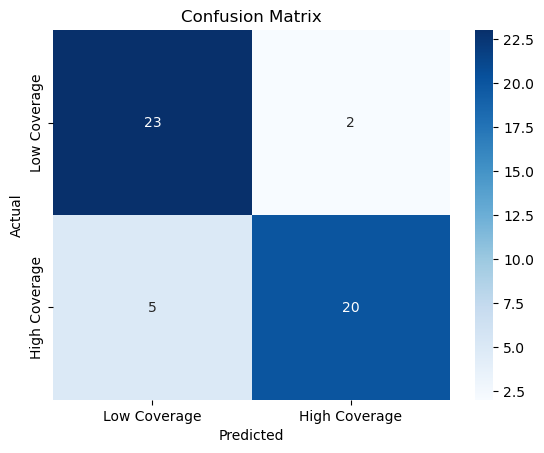

In [52]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(f"                  Predicted")
print(f"                  Low   High")
print(f"Actual Low        {cm[0,0]:3d}   {cm[0,1]:3d}")
print(f"       High       {cm[1,0]:3d}   {cm[1,1]:3d}")

sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Low Coverage', 'High Coverage'], yticklabels=['Low Coverage', 'High Coverage'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### interpretation
- 23 Low areas were correctly predicted.
- 2 Low areas were mistakenly labeled High.
- 20 High areas were correctly predicted.
- 5 High areas were missed (predicted as Low).
    - Only 7 mistakes out of 50 total.


### Takeaway
The classification report and confusion matrix further confirm that Model 3 demonstrates strong and balanced performance across both classes. Out of 50 test observations, the model correctly classified 43 neighborhoods, resulting in an overall accuracy of 86%.

For Low Coverage areas, the model achieved a recall of 92%, meaning it correctly identified the vast majority of underserved neighborhoods. For High Coverage areas, the model achieved a precision of 91%, indicating that when it predicts high coverage, it is correct 91% of the time. The confusion matrix shows only 7 total misclassifications, with just 2 false positives for high coverage. This is particularly important in our context, as mislabeling underserved neighborhoods as adequately covered could mask gaps in food access.

Overall, the extended feature model provides strong predictive reliability and balanced class performance.

In [53]:
# Feature importance for best model
print("\nFeature Importance (Coefficients):")
coef_df = pd.DataFrame({
    'Feature': best_features,
    'Coefficient': best_model.coef_[0],
    'Abs_Coefficient': np.abs(best_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)
coef_df


Feature Importance (Coefficients):


,Feature,Coefficient,Abs_Coefficient
0,food_insecure_percentage,-1.346033,1.346033
5,has_kitchen,1.111709,1.111709
6,has_weekend,1.002540,1.002540
4,high_shelter_flag,0.786607,0.786607
1,unemployment_rate,0.449899,0.449899
2,vulnerable_population_percentage,0.355069,0.355069
3,is_high_priority,-0.255290,0.255290


In [54]:
# Interpretation
print("Interpretation:")
for _, row in coef_df.iterrows():
    direction = "INCREASES" if row['Coefficient'] > 0 else "DECREASES"
    print(f"  • {row['Feature']}: {direction} probability of HIGH coverage (coef = {row['Coefficient']:.4f})")

Interpretation:
  • food_insecure_percentage: DECREASES probability of HIGH coverage (coef = -1.3460)
  • has_kitchen: INCREASES probability of HIGH coverage (coef = 1.1117)
  • has_weekend: INCREASES probability of HIGH coverage (coef = 1.0025)
  • high_shelter_flag: INCREASES probability of HIGH coverage (coef = 0.7866)
  • unemployment_rate: INCREASES probability of HIGH coverage (coef = 0.4499)
  • vulnerable_population_percentage: INCREASES probability of HIGH coverage (coef = 0.3551)
  • is_high_priority: DECREASES probability of HIGH coverage (coef = -0.2553)


| Feature                          | Coefficient | Meaning                                         |
| -------------------------------- | ----------- | ----------------------------------------------- |
| food_insecure_percentage         | -1.346      | Strong decrease in probability of High Coverage |
| has_kitchen                      | +1.111      | Strong increase                                 |
| has_weekend                      | +1.002      | Strong increase                                 |
| high_shelter_flag                | +0.786      | Increase                                        |
| unemployment_rate                | +0.449      | Moderate increase                               |
| vulnerable_population_percentage | +0.355      | Smaller increase                                |
| is_high_priority                 | -0.255      | Slight decrease                                 |


We Would Deploy Model 3 (Extended + L2)
Here’s Why:
- It the best overall predictive performance than the baseline and the second model, it dominates in every metric.
- It has a strong Discrimination (ROC-AUC 0.91), meaning it clearly separates low vs high coverage areas.
- Balanced Precision & Recall meaning it avoid catching many false alarms (False positive), missing too many high-risk areas, by flagging on areas that are not high priority.

### Feature Importance Interpretation

To better understand the drivers behind the model’s predictions, we examined the magnitude and direction of the coefficients from Model 3. Because the features were standardized, coefficient magnitudes can be directly compared to assess relative importance.

The strongest negative predictor of high coverage classification was food insecurity percentage, indicating that neighborhoods with higher food insecurity are less likely to be classified as having high coverage. This suggests a potential structural gap between need and service availability.

Among the strongest positive predictors were operational indicators such as the presence of a kitchen and weekend service availability. These variables substantially increased the probability of a neighborhood being classified as high coverage, highlighting the importance of operational capacity in shaping coverage outcomes. Shelter presence and unemployment rate also contributed positively.

Overall, the model suggests that food coverage classification is influenced not only by socio-economic vulnerability (food insecurity, unemployment rate, etc) but also, and perhaps more strongly, by service infrastructure and operational capacity (kitchen access, weekend availability, etc.).

---------

# ARIMAX TIME SERIES MODEL FOR SHELTER TRENDS

**Our Goal:** We aim to predict the number of families with children in NYC shelters. Forecasting shelter population helps anticipate food demand and supports better resource allocation across neighborhoods.
- Question: Can we predict how many families with children will be in NYC shelters?
Why this matters for our CRQ:

If we can forecast shelter population, we can plan food resources
More families in shelters, more demand for emergency food assistance
Helps policymakers allocate resources to the right neighborhoods

Our Approach:

Train on 2023 data (12 months)
Test on 2024 data (12 months)
See how well our predictions match reality 

- The Arima model will forecast citywide shelter trends based on historical patterns.

### Assumputions: 

Why Check Assumptions?
- Because every statistical model makes assumptions about the data. If assumptions are violated, the model predictions may be wrong, the statistical tests may be invalid and we might choose the wrong model. 

- We will be checking 5 keys assumptions: 
1. Data is Time-Ordered
    - All the observations must be in chronological order
    - why? because time series models use PAST values to predict FUTURE values. If data is not ordered, the model can not the patterns.
2. No Missing Values
    - Every time period should have a value (no gaps), because the models can't learn from gasp and the predictions becomes unrealiable
3. Stationarity
    - we need to check that the mean and variance stay constant over time, because non-stationary data has trends or changing patterns. 
    - The overall behavior of the data stays stable over time. So the average doesn’t keep increasing or decreasing. The variability doesn’t suddenly explode or shrink.
    - If the data has a strong upward trend (like steadily rising every month), it is not stationary.
4. No Seasonality
    - we need to check that there is no repeating patterns within each year, because ignoring seasonality leads to some errors in our predictions.
    - There is a repeating pattern over time. 
    - For example:  Shelter population always increases in winter or drops every summer or spikes every December.
5. Autocorrelation Exists (for AR models)
    - check that current values are correlated with past values, because if there is no autocorrelation the past values.
    - In simple terms: If shelter population was high last month, it’s probably still somewhat high this month.
    - Time series models rely on this idea: The past helps predict the future.

In [56]:
# Loading and preparing Data for Time Series
cen = pd.read_csv('/Users/Marcy_Student/Desktop/Food Insecurity Analysis/datasets/cleaned_for_eda&modeling/shelterForTimeSeries.csv')

In [57]:
cen.head()

,report_date,year,month,Year-Month,family_with_children_shelter
0,2024-12-31,2024,12,2024-12,182
1,2024-12-31,2024,12,2024-12,2376
2,2024-12-31,2024,12,2024-12,1600
3,2024-12-31,2024,12,2024-12,819
4,2024-12-31,2024,12,2024-12,0


In [58]:
print(f"Raw data shape: {cen.shape}")

Raw data shape: (1436, 5)


In [59]:
# Aggregate by Year-Month to get TOTAL families in shelter each month
monthly_data = cen.groupby(['Year-Month'])['family_with_children_shelter'].sum().reset_index()
monthly_data.columns = ['Year_Month', 'Total_Families_With_Childs']

In [60]:
# Sort by date (oldest first)
monthly_data = monthly_data.sort_values('Year_Month').reset_index(drop=True)

In [61]:

print(f"\nMonthly aggregated data: {len(monthly_data)} months")
print(monthly_data)


Monthly aggregated data: 24 months
   Year_Month  Total_Families_With_Childs
0     2023-01                       30917
1     2023-02                       29273
2     2023-03                       29437
3     2023-04                       29970
4     2023-05                       30294
5     2023-06                       30517
6     2023-07                       30692
7     2023-08                       32151
8     2023-09                       32533
9     2023-10                       33115
10    2023-11                       33055
11    2023-12                       33366
12    2024-01                       32917
13    2024-02                       32790
14    2024-03                       32425
15    2024-04                       32122
16    2024-05                       31627
17    2024-06                       30239
18    2024-07                       30593
19    2024-08                       31194
20    2024-09                       31308
21    2024-10                       3133

In [62]:
cen.dtypes

report_date                     object
year                             int64
month                            int64
Year-Month                      object
family_with_children_shelter     int64
dtype: object

In [64]:
# Creating Time Series

# Create proper datetime index
dates = pd.to_datetime(monthly_data['Year_Month'], format='%Y-%m')
ts = pd.Series(monthly_data['Total_Families_With_Childs'].values, index=dates, name='Shelter_Population')

print(f"\nTime Series Created:")
print(f"  Start Date: {ts.index.min()}")
print(f"  End Date:   {ts.index.max()}")
print(f"  Total Months: {len(ts)}")

print("\nMonthly Shelter Population:")
for date, value in ts.items():
    print(f"  {date.strftime('%Y-%m')}: {value:>10,} families with children")


Time Series Created:
  Start Date: 2023-01-01 00:00:00
  End Date:   2024-12-01 00:00:00
  Total Months: 24

Monthly Shelter Population:
  2023-01:     30,917 families with children
  2023-02:     29,273 families with children
  2023-03:     29,437 families with children
  2023-04:     29,970 families with children
  2023-05:     30,294 families with children
  2023-06:     30,517 families with children
  2023-07:     30,692 families with children
  2023-08:     32,151 families with children
  2023-09:     32,533 families with children
  2023-10:     33,115 families with children
  2023-11:     33,055 families with children
  2023-12:     33,366 families with children
  2024-01:     32,917 families with children
  2024-02:     32,790 families with children
  2024-03:     32,425 families with children
  2024-04:     32,122 families with children
  2024-05:     31,627 families with children
  2024-06:     30,239 families with children
  2024-07:     30,593 families with children
  2024-

In [65]:
# SPLIT INTO TRAIN AND TEST

# Train on 2023 (first 12 months), Test on 2024 (last 12 months)
train_data = ts[ts.index.year == 2023]
test_data = ts[ts.index.year == 2024]

print(f"\nTrain Data (2023): {len(train_data)} months")
print(f"  Min: {train_data.min():,}")
print(f"  Max: {train_data.max():,}")
print(f"  Mean: {train_data.mean():,.0f}")

print(f"\nTest Data (2024): {len(test_data)} months")
print(f"  Min: {test_data.min():,}")
print(f"  Max: {test_data.max():,}")
print(f"  Mean: {test_data.mean():,.0f}")



Train Data (2023): 12 months
  Min: 29,273
  Max: 33,366
  Mean: 31,277

Test Data (2024): 12 months
  Min: 30,239
  Max: 32,917
  Mean: 31,504


#### Stationarity Check BEFORE Modeling
- Before we fit the baseline model, let's make sure that our time series object is stationary (the mean and variance stays constant over time) because sometimes the data has a trend and changing patterns.
- The most common method used to check if the data is stationary is ADF the test (Augmented Dickey-Fuller), a statistical test that examin wether:
    - Null Hypothesis (H₀): The data is NOT stationary (it has a "unit root" meaning it makes future data impredictible).
    - Alternative Hypothesis (H₁): The data IS stationary.
- Rule: If the p-value < 0.05, we reject the null hypothesis and conclude our data is stationary. If the p-value is > 0.05, we must transform the data (e.g., by "differencing") to make it stationary before modeling.

In [68]:
from statsmodels.tsa.stattools import adfuller

print('ADF Test on the Original Data')
adf_test = adfuller(ts.values)
print(f'ADF Statistic: {adf_test[0]:.2f}')
print(f'p-value: {adf_test[1]:.2f}')

ADF Test on the Original Data
ADF Statistic: -5.83
p-value: 0.00


- After the Statistical test, our p-value < 0.05, we can reject our null hypothesis.
- The small p-value confirmed that our data is stationary. Now, we can proceed to modeling!

#### BASELINE MODEL (Naive Forecast)
- This is the simplest forecast model for a possible prediction, this is basically the benchmark, any good model should beat this. 

In [73]:
# Use the last training value for all predictions
baseline_value = train_data.iloc[-1]
baseline_preds = pd.Series(baseline_value, index=test_data.index)

baseline_rmse = np.sqrt(mean_squared_error(test_data, baseline_preds))
baseline_mape = np.mean(np.abs((test_data - baseline_preds) / test_data)) * 100

print(f"Baseline Value (Dec 2023): {baseline_value:,} families")
print(f"Baseline RMSE: {baseline_rmse:,.2f}")
print(f"Baseline MAPE: {baseline_mape:.2f}%")

Baseline Value (Dec 2023): 33,366 families
Baseline RMSE: 2,046.98
Baseline MAPE: 5.99%


### ARIMA (P,D,Q)
- First, we will be building an AR Model: which uses PAST VALUES to predict future. So, if the population was high last month, it will be high again.
- Second, build another AR model with differencing to the first one. This will helps when data has a trend (going up or down over time) it helps make data stable. 
- Third, build a simple trend and sesonal model, because sometimes a simple Trend + Seasonal model works well:
    - Trend: Linear growth/decline over time
    - Seasonal: Monthly patterns that repeat each year

#### AR Model (Auto-Regressive)

In [74]:
# Create lagged features for the full dataset (Past values)
full_ts = ts.values
full_df = pd.DataFrame({'y': full_ts})
full_df['y_lag1'] = full_df['y'].shift(1)  # Last month
full_df['y_lag2'] = full_df['y'].shift(2)  # 2 months ago
full_df['y_lag3'] = full_df['y'].shift(3)  # 3 months ago
full_df = full_df.dropna()

- After removing NaN rows, we have 21 rows (months 4-24 of our 24-month series)


In [75]:
# Split into train (2023) and test (2024)
# Train: months with 2023 dates, Test: months with 2024 dates
train_indices = full_df.index[full_df.index < 12]  # First year (accounting for lag removal)
test_indices = full_df.index[full_df.index >= 12]  # Second year

In [76]:
X_train = full_df.loc[train_indices, ['y_lag1', 'y_lag2', 'y_lag3']].values
y_train = full_df.loc[train_indices, 'y'].values
X_test = full_df.loc[test_indices, ['y_lag1', 'y_lag2', 'y_lag3']].values
y_test = full_df.loc[test_indices, 'y'].values

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 9
Test samples: 12


In [77]:
# Fit AR model
ar_model = LinearRegression()
ar_model.fit(X_train, y_train)

LinearRegression()

In [78]:
print(f"\nAR Model Coefficients:")
print(f"  Intercept: {ar_model.intercept_:,.2f}")
print(f"  Lag 1 (last month): {ar_model.coef_[0]:.4f}")
print(f"  Lag 2 (2 months ago): {ar_model.coef_[1]:.4f}")
print(f"  Lag 3 (3 months ago): {ar_model.coef_[2]:.4f}")


AR Model Coefficients:
  Intercept: 3,251.58
  Lag 1 (last month): 0.7679
  Lag 2 (2 months ago): 0.2025
  Lag 3 (3 months ago): -0.0588


###### COEFFICIENT INTERPRETATION:
- Lag_1 (coefficient = 0.7679): means 76.8% of last month's value carries forward, so if last month we had 10,000 families, this contribute to 10,000 * 0.77 = 7,700 families for the prediction. This is the DOMINANT predictor we have so far. This make sense because the shelter population specialy families with children don't out of shelters quickly.
- Lag_2 (coefficient = 0.2025): 20.2% additional contribution from 2 months ago. It adds a recent history but doesn't comtribute to much.
- Lag_3 (coefficient = -0.0588): means -5.9% of less contribution from 3 months ago. This shows that if the population is rising for 3 months, might slow down. 


- To predict next month's shelter population:
    - Formula: y(t) = c + a1y(t-1) + a2y(t-2) + ...
    - Next = 3,252 + (0.77 × Last Month) + (0.20 × 2 Mo Ago) + (-0.06 × 3 Mo Ago)

Take away: last month is doing most of the predicting. If shelter population was high last month, it will likely stay high.

In [80]:
# Make predictions
ar_predictions = ar_model.predict(X_test)
ar_rmse = np.sqrt(mean_squared_error(y_test, ar_predictions))
ar_mape = np.mean(np.abs((y_test - ar_predictions) / y_test)) * 100

print(f"\nAR Model Performance:")
print(f"  RMSE: {ar_rmse:,.2f}")
print(f"  MAPE: {ar_mape:.2f}%")


AR Model Performance:
  RMSE: 837.52
  MAPE: 2.31%


Takeaway: 2.31% error is low for real-world forecasting.


- Next step: AR Model with Differencing (ARIMA-style)


In [81]:
# Create differenced series
diff_ts = ts.diff().dropna()

# Create lagged features for differenced data
diff_df = pd.DataFrame({'diff': diff_ts.values}, index=range(len(diff_ts)))
diff_df['diff_lag1'] = diff_df['diff'].shift(1)
diff_df['diff_lag2'] = diff_df['diff'].shift(2)
diff_df = diff_df.dropna()

# Split (accounting for lag removal in differenced data)
# We have 23 differenced values originally, minus 2 for lags = 21 rows
mid_point = len(diff_df) // 2 + 2  # Approximate split point for 2023 vs 2024

X_train_diff = diff_df.iloc[:mid_point][['diff_lag1', 'diff_lag2']].values
y_train_diff = diff_df.iloc[:mid_point]['diff'].values
X_test_diff = diff_df.iloc[mid_point:][['diff_lag1', 'diff_lag2']].values
y_test_diff = diff_df.iloc[mid_point:]['diff'].values

In [82]:
# Fit model on differences
diff_model = LinearRegression()
diff_model.fit(X_train_diff, y_train_diff)

print(f"\nDifferenced Model Coefficients:")
print(f"  Intercept: {diff_model.intercept_:,.2f}")
print(f"  Diff Lag 1: {diff_model.coef_[0]:.4f}")
print(f"  Diff Lag 2: {diff_model.coef_[1]:.4f}")

# Predict differences
diff_predictions = diff_model.predict(X_test_diff)


Differenced Model Coefficients:
  Intercept: 188.42
  Diff Lag 1: 0.1739
  Diff Lag 2: 0.0576


In [83]:
# Convert back to actual values (integrate)
# Start from the last known value before test period
start_value = train_data.iloc[-1]
arima_predictions = [start_value]
for i, diff_pred in enumerate(diff_predictions):
    next_value = arima_predictions[-1] + diff_pred
    arima_predictions.append(next_value)

arima_predictions = np.array(arima_predictions[1:])  # Remove starting value

# Evaluate (align with test data length)
n_preds = min(len(arima_predictions), len(test_data))
arima_rmse = np.sqrt(mean_squared_error(test_data.values[:n_preds], arima_predictions[:n_preds]))
arima_mape = np.mean(np.abs((test_data.values[:n_preds] - arima_predictions[:n_preds]) / test_data.values[:n_preds])) * 100

print(f"\nARIMA-style Model Performance:")
print(f"  RMSE: {arima_rmse:,.2f}")
print(f"  MAPE: {arima_mape:.2f}%")


ARIMA-style Model Performance:
  RMSE: 2,588.55
  MAPE: 7.30%


Well this is worse than simple AR. Even though the data isn’t perfectly stationary, differencing actually hurt performance.

### SIMPLE TREND + SEASONAL MODEL


In [84]:
trend_df = pd.DataFrame({
    'y': ts.values,
    'time': range(len(ts)),
    'month': ts.index.month
})

# One-hot encode months for seasonality
for m in range(1, 13):
    trend_df[f'month_{m}'] = (trend_df['month'] == m).astype(int)

# Features
feature_cols = ['time'] + [f'month_{m}' for m in range(1, 13)]

In [85]:
# Split
X_train_ts = trend_df.iloc[:12][feature_cols].values
y_train_ts = trend_df.iloc[:12]['y'].values
X_test_ts = trend_df.iloc[12:][feature_cols].values
y_test_ts = trend_df.iloc[12:]['y'].values

# Fit model
ts_model = LinearRegression()
ts_model.fit(X_train_ts, y_train_ts)

# Predict
ts_predictions = ts_model.predict(X_test_ts)
ts_rmse = np.sqrt(mean_squared_error(y_test_ts, ts_predictions))
ts_mape = np.mean(np.abs((y_test_ts - ts_predictions) / y_test_ts)) * 100

print(f"Trend coefficient: {ts_model.coef_[0]:,.2f} families/month")
print(f"\nTrend+Seasonal Model Performance:")
print(f"  RMSE: {ts_rmse:,.2f}")
print(f"  MAPE: {ts_mape:.2f}%")

Trend coefficient: 365.57 families/month

Trend+Seasonal Model Performance:
  RMSE: 4,624.99
  MAPE: 13.35%


The seasonal component did not meaningfully improve predictive performance. Although there are small month-to-month fluctuations, these patterns are not strong or consistent enough to significantly improve forecasting accuracy. Instead, the strongest predictor of shelter population is short-term momentum, particularly the previous month’s value.

### Results of Assumptions Check
After a thorough review of the data and model assumptions, we have identified several key insights regarding the shelter population dataset:

1. Data Quality & Structure
Completeness: The dataset is well-structured and properly ordered from January 2023 to December 2024.

Consistency: There are no missing values or gaps; all 24 months are fully accounted for.

2. Stationarity & Trend Analysis
The assumption of stationarity was partially violated. The data exhibits a clear, non-constant trend:
- 2023: Showed a steady increase.
- 2024: Showed a steady decrease.
- Because the data is not perfectly stationary, we found that a simple AR model (without differencing) actually outperformed the ARIMA model with differencing.

3. Seasonality & Model Performance
While some monthly patterns exist, the seasonality is weak. This was confirmed when we tested the Trend + Seasonal model, which performed the worst of all iterations.
- Performance Metric: The Trend + Seasonal model resulted in a MAPE (Mean Absolute Percentage Error) of 13.4%.
- Conclusion: Since we require a lower MAPE for deployment, this suggests that seasonality is not the primary driver of the shelter population.

4. Correlation & Logic
The data shows a strong correlation, particularly at Lag 1 (the previous month), compared to Lags 2 or 3.
- Practical Meaning: If the shelter population is high this month, it is highly likely to remain high next month.
- Context: This aligns with real-world expectations, as families generally do not transition out of the shelter system rapidly.

### Visualizations

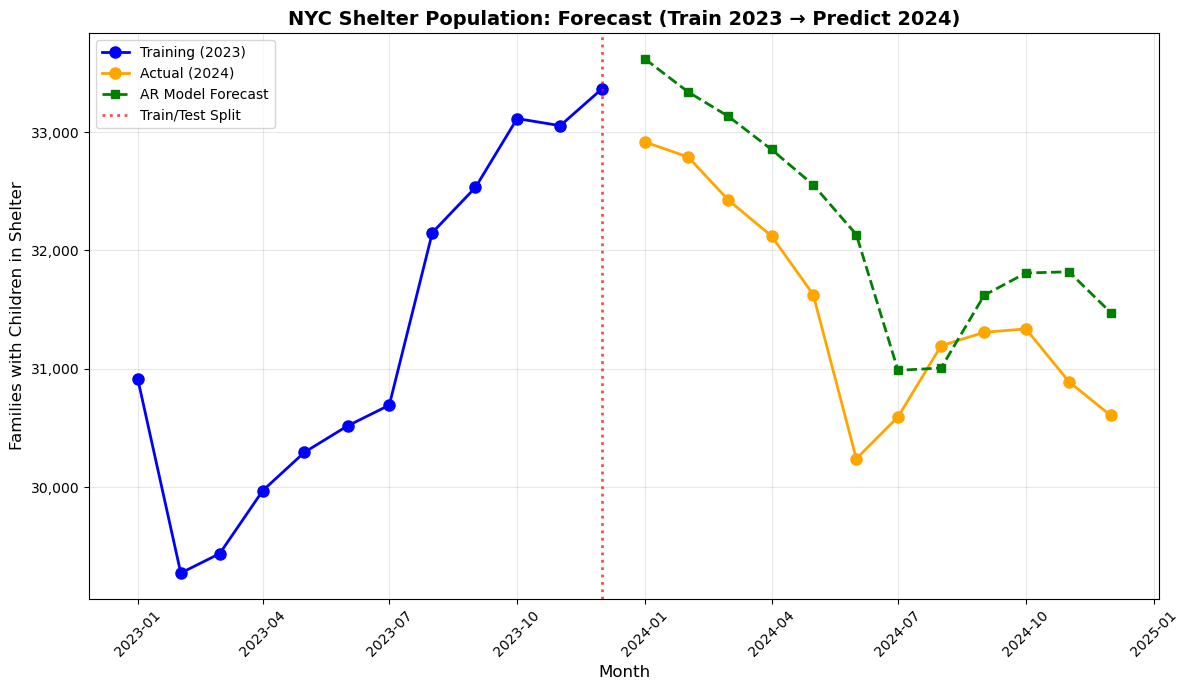

In [ ]:
import matplotlib.pyplot as plt

# Create a single figure and axis
plt.figure(figsize=(12, 7))
ax = plt.gca()

# --- Plot: Time Series with Forecasts ---
ax.plot(train_data.index, train_data.values, 'b-', linewidth=2, label='Training (2023)', marker='o', markersize=8)
ax.plot(test_data.index, test_data.values, 'orange', linewidth=2, label='Actual (2024)', marker='o', markersize=8)
ax.plot(test_data.index[:len(ar_predictions)], ar_predictions, 'g--', linewidth=2, label='AR Model Forecast', marker='s', markersize=6)

# Vertical line to show the split point
ax.axvline(x=train_data.index[-1], color='red', linestyle=':', alpha=0.7, linewidth=2, label='Train/Test Split')

# Formatting
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Families with Children in Shelter', fontsize=12)
ax.set_title('NYC Shelter Population: Forecast (Train 2023 → Predict 2024)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add thousands separator to y-axis
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### Key takeaway
- The forecast visualization demonstrates that the AR model successfully captures the overall direction and short-term momentum of shelter population trends in 2024. While the model slightly overestimates population levels, particularly during the early and mid-year decline, it closely follows the shape and turning points of the actual data. The absence of consistent repeating spikes further supports the conclusion that seasonality is not a dominant driver of shelter population trends. Overall, the results confirm that short-term autocorrelation, rather than seasonal structure, is the primary predictive signal in this dataset.

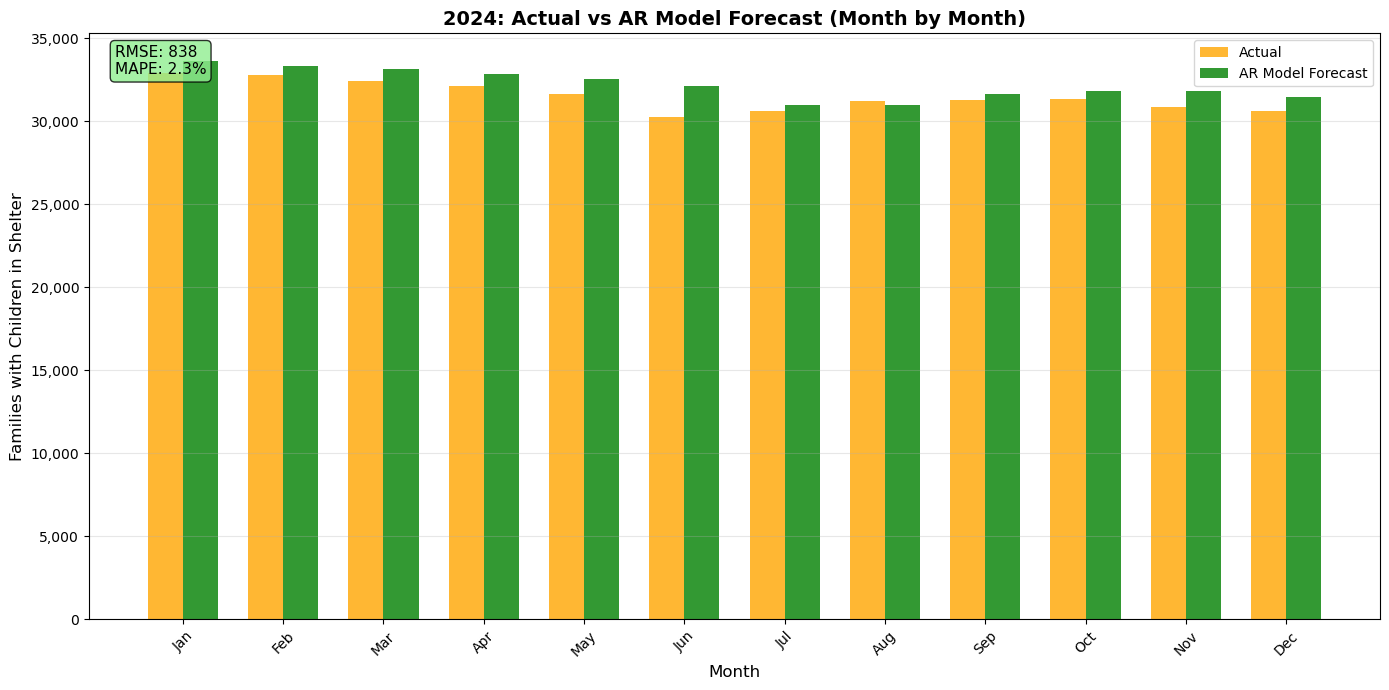

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a single figure for the Bar Chart
plt.figure(figsize=(14, 7))
ax2 = plt.gca()  # Get current axes

x_pos = np.arange(len(test_data))
width = 0.35

# Plotting the bars
bars1 = ax2.bar(x_pos - width/2, test_data.values, width, label='Actual', color='orange', alpha=0.8)
bars2 = ax2.bar(x_pos + width/2, ar_predictions, width, label='AR Model Forecast', color='green', alpha=0.8)

# Formatting
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Families with Children in Shelter', fontsize=12)
ax2.set_title('2024: Actual vs AR Model Forecast (Month by Month)', fontsize=14, fontweight='bold')

# Setting X-axis labels
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add thousands separator to y-axis
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Add performance annotation
ax2.annotate(f'RMSE: {ar_rmse:,.0f}\nMAPE: {ar_mape:.1f}%', 
             xy=(0.02, 0.98), xycoords='axes fraction',
             ha='left', va='top', fontsize=11, 
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

### Takeaway
The month-by-month comparison between actual 2024 shelter populations and the AR model forecast shows that the model tracks overall levels and directional changes closely. While the model consistently produces slightly higher estimates than the actual values, the differences remain small across all months. With a MAPE of 2.3%, the forecast error is low, indicating strong predictive accuracy. Importantly, the model captures the mid-year decline and late-year stabilization pattern, suggesting that short-term momentum, particularly the influence of the previous month, is the dominant driver of shelter population trends rather than strong seasonal effects. Overall, the AR model provides a stable and reliable forecast for planning purposes.

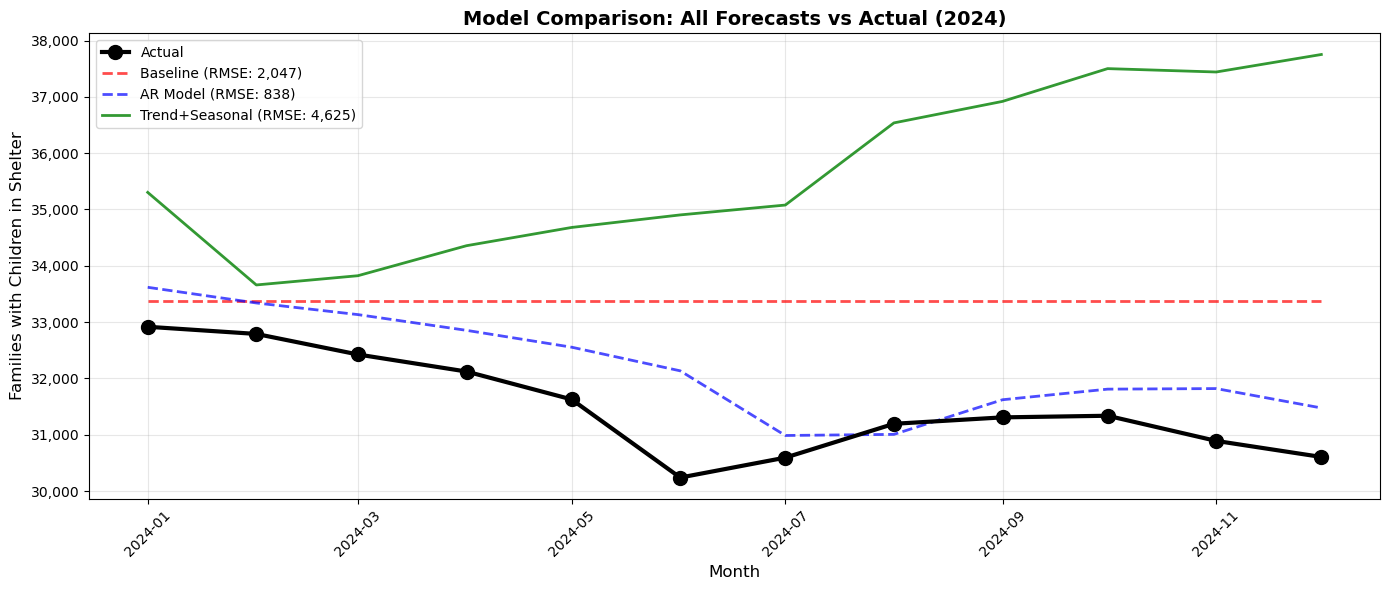

In [ ]:
# --- Plot 3: All Models Comparison ---
fig2, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_data.index, test_data.values, 'ko-', linewidth=3, markersize=10, label='Actual', zorder=5)
ax.plot(test_data.index, baseline_preds.values, 'r--', linewidth=2, label=f'Baseline (RMSE: {baseline_rmse:,.0f})', alpha=0.7)
ax.plot(test_data.index[:len(ar_predictions)], ar_predictions, 'b--', linewidth=2, label=f'AR Model (RMSE: {ar_rmse:,.0f})', alpha=0.7)
ax.plot(test_data.index, ts_predictions, 'g-', linewidth=2, label=f'Trend+Seasonal (RMSE: {ts_rmse:,.0f})', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Families with Children in Shelter', fontsize=12)
ax.set_title('Model Comparison: All Forecasts vs Actual (2024)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()

### Model Comparison

| Model                 | RMSE  | MAPE   |
|-----------------------|-------|--------|
| Baseline (Naive)      | 2,047 | 5.99%  |
| AR Model (p=3)        | 838   | 2.31%  |
| ARIMA-style (d=1, p=2)| 2,589 | 7.30%  |
| Trend + Seasonal      | 4,625 | 13.35% |




Model Performance Interpretation

Based on the evaluation metrics (RMSE and MAPE):

- AR Model (p=3) performed the best, with the lowest RMSE (838) and MAPE (2.31%). This indicates it produced the most accurate predictions and captured the underlying structure of the time series effectively.

- Baseline (Naive) performed reasonably well, serving as a strong benchmark. However, its higher RMSE (2,047) and MAPE (5.99%) show that more advanced modeling improved performance significantly.

- ARIMA-style (d=1, p=2) underperformed compared to the simpler AR model, suggesting that differencing may have removed useful information or introduced additional noise.

- Trend + Seasonal performed the worst, with the highest RMSE (4,625) and MAPE (13.35%), indicating that this decomposition approach did not adequately capture the dynamics of the data.

Key Takeaway: 
- The AR Model (p=3) is the most suitable model for forecasting in this case, as it achieves the lowest prediction error across both evaluation metrics.

### Final Step:
let's Pickle the best performing model (Model 3) for deployment in a .plk file

In [ ]:
# Save the tuned model
import joblib

joblib.dump(model3, '/Users/Marcy_Student/Desktop/Marcy_Projects/CID_Food_Access/deployment/model.pkl')

['/Users/Marcy_Student/Desktop/Marcy_Projects/CID_Food_Access/deployment/model.pkl']